In [6]:
import optuna
import warnings
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, ConstantKernel as C, WhiteKernel
)
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

 
# Silence Optuna's experimental feature warnings and
# trial-by-trial progress output — keep your console clean
#optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
import sys
print(sys.version)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [ ]:
#Function to add data points each week.
current_week = 14   # CHANGE THIS EACH WEEK



# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_5\initial_inputs.npy")
    Y = np.load(r"function_5\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_5/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_5/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")


In [8]:
# =====================================================
# SAVE UPDATED DATA

# =====================================================


np.save(
    f"function_5/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_5/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_5/w{current_week}_inputs.npy"
)

print(
    f"function_5/w{current_week}_outputs.npy"
)


Saved files:
function_5/w14_inputs.npy
function_5/w14_outputs.npy


In [9]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_5/w14_inputs.npy")
Y = np.load("function_5/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.8f} | Gap={abs(Y[i]):.8f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:      {np.max(Y):.8f}")
print(f"Gap to zero: {abs(np.max(Y)):.8f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | "
          f"Y={Y[i]:.8f} | X={vals}")

print("\nKey dimension values in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.8f} | "
          f"x1={X[i,0]:.6f} | "
          f"x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f}")

All points ranked best to worst:
  Y=8662.40500125 | Gap=8662.40500125 | X=0.999999-0.999999-0.999999-0.999999
  Y=8646.27271346 | Gap=8646.27271346 | X=0.999999-0.999193-0.999999-0.999971
  Y=8464.51820642 | Gap=8464.51820642 | X=0.998704-0.993476-0.997843-0.999628
  Y=4849.18142977 | Gap=4849.18142977 | X=0.946111-0.741586-0.999999-0.999999
  Y=4039.81108838 | Gap=4039.81108838 | X=0.897783-0.695170-0.998191-0.998986
  Y=3006.12919859 | Gap=3006.12919859 | X=0.328445-0.858913-0.997843-0.999628
  Y=2998.04872270 | Gap=2998.04872270 | X=0.308705-0.858913-0.997843-0.999628
  Y=2959.27373125 | Gap=2959.27373125 | X=0.295933-0.852480-0.999575-0.998945
  Y=2700.13637305 | Gap=2700.13637305 | X=0.324061-0.816725-0.996481-0.998660
  Y=2404.09732678 | Gap=2404.09732678 | X=0.216871-0.813169-0.972334-0.997989
  Y=2232.71494339 | Gap=2232.71494339 | X=0.295736-0.839697-0.971175-0.963312
  Y=1456.43038267 | Gap=1456.43038267 | X=0.909940-0.846440-0.708276-0.817887
  Y=1088.85961820 | Gap=1088.85

## Function 5 — Surrogate Strategy and Candidate Generation

Function 5 presented one of the most complex surrogate configurations in the 
project, reflecting the need to balance **tight local exploitation** of confirmed 
good regions against **global exploration** of potentially better undiscovered areas.

### Candidate Generation — Four Approaches

Rather than relying on a single candidate pool, four distinct approaches were 
used to generate query candidates each week, each serving a different strategic purpose:

**Uniform sampling** generated candidates randomly across the confirmed good 
ranges for all four dimensions — providing broad coverage of the known promising 
region without concentrating too tightly around any single point.

**Local noise** added small random adjustments drawn from a normal distribution centred on the confirmed best point (std=0.015) around the 
confirmed best point. This enabled fine-grained exploitation of the immediate 
neighbourhood of the best observed result.

**UCB exploration** (added week 10) deliberately searched regions with high 
uncertainty — areas of the input space rarely or never sampled. With beta=5, 
UCB strongly rewards uncertainty over predicted performance, making it the 
primary tool for escaping local optima. This was the strategy that identified 
the true peak region in week 11-12 after six weeks anchored to a local optimum.

### Surrogate Models — Six Candidates Compared Weekly

Each week six candidate suggestions were generated from different surrogate 
and acquisition function combinations, then competed through range validation 
and plausibility checks before a final submission was selected:

| Candidate | Surrogate | Pool | Purpose |
|-----------|-----------|------|---------|
| GP (uniform) | Gaussian Process + EI | Uniform ranges | Broad exploitation with uncertainty |
| SVR (uniform) | Support Vector Regression | Uniform ranges | Alternative landscape model, uniform space |
| GP (local) | Gaussian Process + EI | Local noise | Fine exploitation near confirmed best |
| SVR (local) | Support Vector Regression | Local noise | Alternative model, tight neighbourhood |
| Optuna TPE | Tree-structured Parzen Estimator | Full bounds | Captures joint dimension dependencies |
| Optuna CMA-ES | Covariance Matrix Adaptation | Full bounds | Tight local exploitation, learns active dimensions |
| UCB Explore | Gaussian Process + UCB (β=5) | Unexplored region | Global exploration, rewards uncertainty |

### Why Multiple Surrogates?

No single surrogate consistently outperformed the others across all weeks. 
**GP** tends to over-explore in uncertain regions — useful early but unreliable 
for fine exploitation. **SVR** is more conservative and handles tight clusters 
better but can miss genuine improvements in unexplored areas. **TPE** captures 
joint relationships between dimensions that GP and SVR model independently. 
**CMA-ES** learns which dimensions are active and concentrates search there — 
particularly valuable once the gradient toward [1,1,1,1] was confirmed in 
weeks 11-12.

The final submission each week was selected by **LOO cross-validation** 
(lowest RMSE surrogate takes priority), subject to range validation 
(all dimensions within confirmed empirical bounds) and a plausibility 
check (prediction within 70%-130% of best real Y).

C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Fitted kernel length scales:
  x1: 2.4790
  x2: 2.2002
  x3: 0.9784
  x4: 10.0000 ← hitting bound

Best real point: [0.999999 0.999999 0.999999 0.999999]
Best real Y:     8662.4050


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\si


=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 395.94
SVR LOO RMSE: 1522.24
Primary surrogate: GP

Focused candidates (uniform): 500000
Novel candidates (local):   202920


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:302: FutureWarning: `x0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:307: FutureWarning: `sigma0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)



--- UCB Global Exploration ---
  Suggestion:         0.999902-0.999170-0.999778-0.970566
  GP predicted Y:     8590.2359
  Distance from best: 0.0294
  x1=0.9999 | x2=0.9992 | x3=0.9998 | x4=0.9706
  Note: UCB pred unreliable in unexplored region — high std inflates the score

FULL COMPARISON — Function 5

--- GP  (uniform) ---
  Suggestion:         0.999955-0.999379-0.999213-0.965268
  Predicted Y:        8581.6385
  Distance from best: 0.0347
  x1=1.0000 | x2=0.9994 | x3=0.9992 | x4=0.9653

--- SVR (uniform) ---
  Suggestion:         0.909220-0.910957-0.999637-0.999815
  Predicted Y:        4082.0777
  Distance from best: 0.1272
  x1=0.9092 | x2=0.9110 | x3=0.9996 | x4=0.9998

--- GP  (local) ---
  Suggestion:         0.999999-0.999999-0.999999-0.940112
  Predicted Y:        8597.7037
  Distance from best: 0.0599
  x1=1.0000 | x2=1.0000 | x3=1.0000 | x4=0.9401

--- SVR (local) ---
  Suggestion:         0.966743-0.942430-0.999999-0.999999
  Predicted Y:        4046.5009
  Distance fr

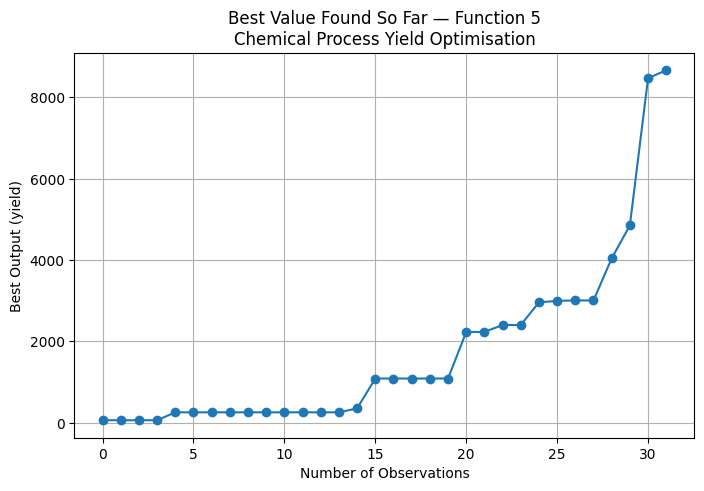


Top 5 real evaluated points:
  Y=8662.4050 | X=1.0000-1.0000-1.0000-1.0000
  Y=8464.5182 | X=0.9987-0.9935-0.9978-0.9996
  Y=4849.1814 | X=0.9461-0.7416-1.0000-1.0000
  Y=4039.8111 | X=0.8978-0.6952-0.9982-0.9990
  Y=3006.1292 | X=0.3284-0.8589-0.9978-0.9996


In [5]:
# =====================================================
# FUNCTION 5 — 4D Chemical Process Yield
# Week 8: Optuna TPE + CMA-ES added as new candidates
# Week 8 fix: GP length_scale_bounds tightened (1e-3, 10)
# =====================================================

import optuna
import warnings
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, ConstantKernel as C, WhiteKernel
)
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =====================================================
# GP MODEL — week 8: tightened length_scale_bounds
# Upper bound reduced 1e3 → 10 after week 8 output
# showed x1/x3 hitting 1000 bound (same failure as F3)
# F5 is confirmed unimodal — all 4 dims are meaningful,
# none should be ignored. Bound of 10 prevents GP
# collapsing onto best point and extrapolating nonsense.
# =====================================================
kernel = (
    C(1.0, (1e-3, 1e5))
    * RBF(length_scale=[0.1, 0.1, 0.1, 0.1],
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-5,
                  noise_level_bounds=(1e-12, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# ACQUISITION FUNCTION
# =====================================================
def expected_improvement(X_candidates_scaled, gp,
                          Y_ref, xi=0.01):
    mean, std = gp.predict(X_candidates_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# FIT GP AND SVR
# =====================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
gp.fit(X_scaled, Y)

# Print kernel length scales each week
print("Fitted kernel length scales:")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" if ls >= 9.5 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

# SVR — epsilon reduced to 1 from 10
svr = SVR(
    kernel='rbf',
    C=1000,
    epsilon=1,
    gamma='scale'
)
svr.fit(X_scaled, Y)

best_point = X[np.argmax(Y)]
print(f"\nBest real point: {best_point}")
print(f"Best real Y:     {np.max(Y):.4f}")

# =====================================================
# LOO CROSS VALIDATION
# =====================================================
loo        = LeaveOneOut()
gp_errors  = []
svr_errors = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    scaler_cv = StandardScaler()
    X_train_s = scaler_cv.fit_transform(X_train)
    X_test_s  = scaler_cv.transform(X_test)

    gp_cv = GaussianProcessRegressor(
        kernel=kernel, random_state=42,
        normalize_y=True, alpha=1e-5)
    gp_cv.fit(X_train_s, Y_train)
    gp_errors.append(
        (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)

    svr_cv = SVR(kernel='rbf', C=1000,
                 epsilon=1, gamma='scale')
    svr_cv.fit(X_train_s, Y_train)
    svr_errors.append(
        (svr_cv.predict(X_test_s)[0] - Y_test[0])**2)

gp_rmse       = np.sqrt(np.mean(gp_errors))
svr_rmse      = np.sqrt(np.mean(svr_errors))
primary_model = "GP" if gp_rmse < svr_rmse else "SVR"

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.2f}")
print(f"SVR LOO RMSE: {svr_rmse:.2f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# GENERATE CANDIDATES — two approaches (unchanged)
# =====================================================
np.random.seed(42)
n_candidates = 500000
dim          = X.shape[1]

# Approach 1 — uniform in confirmed ranges
x1_u = np.random.uniform(0.90, 0.999999, n_candidates)  # push toward peak week 12
x2_u = np.random.uniform(0.70, 0.999999, n_candidates)  # push toward peak week 12
x3_u = np.random.uniform(0.96, 0.999999, n_candidates)
x4_u = np.random.uniform(0.96, 0.999999, n_candidates)

X_focused        = np.column_stack([x1_u, x2_u, x3_u, x4_u])
X_focused_scaled = scaler.transform(X_focused)
print(f"\nFocused candidates (uniform): {len(X_focused)}")

# Approach 2 — local noise around best point
n_local = int(n_candidates * 0.5)
noise   = np.random.normal(0, 0.015, size=(n_local, dim))
X_local = np.clip(best_point + noise, 0.0, 0.999999)
X_local[:, 1] = np.clip(X_local[:, 1], 0.70, 0.999999)  # push toward peak week 12

min_dists_l  = cdist(X_local, X).min(axis=1)
X_novel_l    = X_local[min_dists_l >= 0.005]
X_novel_l_s  = scaler.transform(X_novel_l)
print(f"Novel candidates (local):   {len(X_novel_l)}")

# =====================================================
# SCORE GP/SVR CANDIDATES (unchanged)
# =====================================================

# Uniform — GP EI
ei_scores_u  = expected_improvement(
    X_focused_scaled, gp, Y, xi=0.01)
x_submit_gp  = X_focused[np.argmax(ei_scores_u)]
pred_gp      = gp.predict(scaler.transform([x_submit_gp]))[0]
dist_gp      = np.linalg.norm(x_submit_gp - best_point)

# Uniform — SVR
svr_scores_u = svr.predict(X_focused_scaled)
x_submit_svr = X_focused[np.argmax(svr_scores_u)]
pred_svr     = svr.predict(scaler.transform([x_submit_svr]))[0]
dist_svr     = np.linalg.norm(x_submit_svr - best_point)

# Local — GP EI
ei_scores_l   = expected_improvement(X_novel_l_s, gp, Y, xi=0.01)
x_submit_gp_l = X_novel_l[np.argmax(ei_scores_l)]
pred_gp_l     = gp.predict(scaler.transform([x_submit_gp_l]))[0]
dist_gp_l     = np.linalg.norm(x_submit_gp_l - best_point)

# Local — SVR
svr_scores_l   = svr.predict(X_novel_l_s)
x_submit_svr_l = X_novel_l[np.argmax(svr_scores_l)]
pred_svr_l     = svr.predict(scaler.transform([x_submit_svr_l]))[0]
dist_svr_l     = np.linalg.norm(x_submit_svr_l - best_point)

# =====================================================
# OPTUNA INTEGRATION — week 8 addition
# Bounds mirror confirmed ranges + existing clip floors
# x2 upper = 0.86 enforces the clip inside Optuna itself
# =====================================================
BOUNDS_F5 = {
    "x1": (0.90,  0.999999),  # push toward peak week 12
    "x2": (0.70,  0.999999),  # push toward peak week 12
    "x3": (0.96,   0.999999),
    "x4": (0.96,   0.999999),
}

def build_warm_study(X_obs, Y_obs, bounds, sampler,
                     direction="maximize"):
    """Load existing observations into Optuna study so
    sampler starts from full history — no cold start."""
    study = optuna.create_study(direction=direction,
                                sampler=sampler)
    distributions = {
        name: optuna.distributions.FloatDistribution(lo, hi)
        for name, (lo, hi) in bounds.items()
    }
    for x_row, y_val in zip(X_obs, Y_obs):
        # Clip to bounds — handles any historical point
        # that sits just outside current confirmed range
        params = {
            name: float(np.clip(x_row[i], lo, hi))
            for i, (name, (lo, hi)) in enumerate(
                bounds.items())
        }
        study.add_trial(optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(y_val)
        ))
    return study

# --- Optuna TPE (multivariate) ---
# Captures joint dimension dependencies:
# e.g. x2 high AND x3/x4 high together
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    tpe_sampler = optuna.samplers.TPESampler(
        multivariate=True,
        n_startup_trials=10,   # >10 obs so fires immediately
        seed=42
    )
study_tpe = build_warm_study(X, Y, BOUNDS_F5, tpe_sampler)
trial_tpe = study_tpe.ask()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    x_tpe = np.array([
        trial_tpe.suggest_float(name, lo, hi)
        for name, (lo, hi) in BOUNDS_F5.items()
    ])
pred_tpe = gp.predict(scaler.transform([x_tpe]))[0]
dist_tpe = np.linalg.norm(x_tpe - best_point)

# --- Optuna CMA-ES ---
# Tight local exploitation around best_point
# sigma0 = min_range / 6 (CMA-ES standard rule)
# For F5: narrowest range = x1 (0.12) → sigma0 = 0.020
sigma0 = min(hi - lo for lo, hi in BOUNDS_F5.values()) / 6.0
sigma0 = max(sigma0, 0.005)   # floor — don't go too tight

cmaes_sampler = optuna.samplers.CmaEsSampler(
    x0={
        name: float(np.clip(best_point[i], lo, hi))
        for i, (name, (lo, hi)) in enumerate(BOUNDS_F5.items())
    },
    sigma0=sigma0,
    seed=42
)
study_cmaes = build_warm_study(X, Y, BOUNDS_F5, cmaes_sampler)
trial_cmaes = study_cmaes.ask()
x_cmaes = np.array([
    trial_cmaes.suggest_float(name, lo, hi)
    for name, (lo, hi) in BOUNDS_F5.items()
])
pred_cmaes = gp.predict(scaler.transform([x_cmaes]))[0]
dist_cmaes = np.linalg.norm(x_cmaes - best_point)

# =====================================================
# UCB GLOBAL EXPLORATION — week 10 addition
# Motivation: another student reported Y > 8000,
# suggesting a much higher peak exists in an
# unexplored region of the space.
# Best of 3006 may only be ~37% of true maximum.
# Classic BO trap: high early returns created
# anchoring bias toward exploitation too early.
# Reference: Brochu, Cora & de Freitas (2010)
#
# Strategy: keep x3/x4 near 1.0 (robustly good)
# Explore x1=0.40-0.90, x2=0.20-0.70 — never tested
# with high x3/x4. UCB beta=5 strongly rewards
# high uncertainty (unexplored regions).
# =====================================================
def upper_confidence_bound(X_cands_scaled, gp,
                            beta=5.0):
    mean, std = gp.predict(X_cands_scaled,
                            return_std=True)
    return mean.reshape(-1) + beta * std.reshape(-1)

# Generate exploration candidates
np.random.seed(99)   # different seed from exploitation
n_explore = 500000

x1_exp = np.random.uniform(0.90, 0.999999, n_explore)  # push toward peak week 12
x2_exp = np.random.uniform(0.70, 0.999999, n_explore)  # push toward peak week 12
x3_exp = np.random.uniform(0.97, 0.999999, n_explore)
x4_exp = np.random.uniform(0.97, 0.999999, n_explore)

X_explore        = np.column_stack([x1_exp, x2_exp,
                                     x3_exp, x4_exp])
X_explore_scaled = scaler.transform(X_explore)

# Score with UCB — high beta rewards uncertainty
ucb_scores  = upper_confidence_bound(
    X_explore_scaled, gp, beta=5.0)
x_ucb       = X_explore[np.argmax(ucb_scores)]
pred_ucb    = gp.predict(
    scaler.transform([x_ucb]))[0]
dist_ucb    = np.linalg.norm(x_ucb - best_point)

print(f"\n--- UCB Global Exploration ---")
print(f"  Suggestion:         "
      f"{'-'.join([f'{x:.6f}' for x in x_ucb])}")
print(f"  GP predicted Y:     {pred_ucb:.4f}")
print(f"  Distance from best: {dist_ucb:.4f}")
print(f"  x1={x_ucb[0]:.4f} | x2={x_ucb[1]:.4f} | "
      f"x3={x_ucb[2]:.4f} | x4={x_ucb[3]:.4f}")
print(f"  Note: UCB pred unreliable in unexplored "
      f"region — high std inflates the score")

# =====================================================
# FULL COMPARISON — 7 options (6 existing + UCB)
# =====================================================
print("\n" + "="*55)
print("FULL COMPARISON — Function 5")
print("="*55)

all_options = {
    "GP  (uniform)":   (x_submit_gp,    pred_gp,    dist_gp),
    "SVR (uniform)":   (x_submit_svr,   pred_svr,   dist_svr),
    "GP  (local)":     (x_submit_gp_l,  pred_gp_l,  dist_gp_l),
    "SVR (local)":     (x_submit_svr_l, pred_svr_l, dist_svr_l),
    "Optuna TPE":      (x_tpe,          pred_tpe,   dist_tpe),
    "Optuna CMA-ES":   (x_cmaes,        pred_cmaes, dist_cmaes),
    "UCB Explore":     (x_ucb,          pred_ucb,   dist_ucb),
}

for name, (x_sub, pred, dist) in all_options.items():
    print(f"\n--- {name} ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  Predicted Y:        {pred:.4f}")
    print(f"  Distance from best: {dist:.4f}")
    print(f"  x1={x_sub[0]:.4f} | x2={x_sub[1]:.4f} | "
          f"x3={x_sub[2]:.4f} | x4={x_sub[3]:.4f}")

# =====================================================
# SUBMISSION SELECTION
# Week 10: range validation + plausibility added
# x2 < 0.850 caused week 9 regression (Y=2700)
# x1 > 0.35 is outside confirmed range
# Plausibility: 70%-130% of best real Y
# =====================================================
threshold = 0.3  # increase to .3 week 11 — two data points now in region

confirmed_f5 = {
    'x1': (0.90,  0.999999),  # push toward peak week 12
    'x2': (0.70,  0.999999),  # push toward peak week 12
    'x3': (0.96,  0.999999),
    'x4': (0.96,  0.999999),
}

def passes_range_f5(x_sub):
    for dim_name, (low, high) in confirmed_f5.items():
        idx = int(dim_name[1]) - 1
        if not (low <= x_sub[idx] <= high):
            return False
    return True

best_real_y        = np.max(Y)
plausibility_floor = 0.70 * best_real_y
plausibility_ceil  = 1.30 * best_real_y

def plausible_f5(pred):
    return plausibility_floor <= pred <= plausibility_ceil

print(f"\n{'='*55}")
print("SUBMISSION SELECTION")
print(f"{'='*55}")
print(f"Plausibility bounds: "
      f"[{plausibility_floor:.0f}, {plausibility_ceil:.0f}]")

candidates_final = []
for name, (x_sub, pred, dist) in all_options.items():
    in_range = passes_range_f5(x_sub)
    eligible = (dist <= threshold) and in_range
    reason   = ""
    if dist > threshold:
        reason = f"dist={dist:.4f} > {threshold}"
    elif not in_range:
        reason = "outside confirmed range"
    status = "eligible" if eligible \
        else f"excluded — {reason}"
    print(f"  {name}: {status} | "
          f"pred={pred:.0f} | "
          f"plausible={plausible_f5(pred)}")
    if eligible:
        candidates_final.append((name, x_sub, pred, dist))

if len(candidates_final) == 0:
    print("No candidates eligible — using closest in range")
    in_range_opts = [(n, x, p, d)
                     for n, (x, p, d) in all_options.items()
                     if passes_range_f5(x)]
    if in_range_opts:
        x_final      = min(in_range_opts,
                           key=lambda t: t[3])[1]
        chosen_model = "closest in range (fallback)"
    else:
        x_final      = min(all_options.items(),
                           key=lambda t: t[1][2])[1][0]
        chosen_model = "closest (fallback)"
else:
    # Primary model wins if plausible
    primary_eligible = [
        c for c in candidates_final
        if primary_model.upper() in c[0].upper()]
    primary_plausible = [
        c for c in primary_eligible
        if plausible_f5(c[2])]

    if primary_plausible:
        best_eligible = max(primary_plausible,
                            key=lambda t: t[2])
        x_final      = best_eligible[1]
        chosen_model = best_eligible[0]
    else:
        all_plausible = [c for c in candidates_final
                         if plausible_f5(c[2])]
        if all_plausible:
            best_eligible = max(all_plausible,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(plausibility override)")
            print(f"\n⚠ Primary failed plausibility — "
                  f"overriding to {best_eligible[0]}")
        else:
            best_eligible = max(candidates_final,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(all implausible)")

submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - best_point)

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP  uniform predicted Y:    {pred_gp:.4f}")
print(f"SVR uniform predicted Y:    {pred_svr:.4f}")
print(f"GP  local predicted Y:      {pred_gp_l:.4f}")
print(f"SVR local predicted Y:      {pred_svr_l:.4f}")
print(f"Optuna TPE predicted Y:     {pred_tpe:.4f}")
print(f"Optuna CMA-ES predicted Y:  {pred_cmaes:.4f}")
print(f"UCB Explore predicted Y:    {pred_ucb:.4f}")
print(f"UCB Explore x1={x_ucb[0]:.4f} x2={x_ucb[1]:.4f}")
print(f"Best real Y:                {np.max(Y):.4f}")
print(f"Distance from best:         {dist_final:.4f}")
print(f"LOO primary model:          {primary_model} "
      f"(GP={gp_rmse:.1f}, SVR={svr_rmse:.1f})")
print(f"Optuna CMA-ES sigma0:       {sigma0:.4f}")
print(f"Dataset size:               {len(Y)}")

# =====================================================
# TOP 10 CANDIDATES BY EI — uniform set (unchanged)
# =====================================================
top_ei_indices = np.argsort(ei_scores_u)[-10:][::-1]
print("\nTop 10 GP candidates by EI (uniform):")
for idx in top_ei_indices:
    vals = "-".join([f"{v:.4f}" for v in X_focused[idx]])
    pred = gp.predict(
        scaler.transform([X_focused[idx]]))[0]
    print(f"  EI={ei_scores_u[idx]:.4f} | "
          f"Pred Y={pred:.4f} | X={vals}")

# =====================================================
# PLOT PROGRESS (unchanged)
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.title("Best Value Found So Far — Function 5\n"
          "Chemical Process Yield Optimisation")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output (yield)")
plt.grid(True)
plt.show()

# =====================================================
# TOP 5 REAL RESULTS (unchanged)
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 real evaluated points:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.4f} | X={vals}")